# Statistical Analysis: Poor Health & Food

Using PLACES, a CDC health dataset, this notebook will outline how to use regression and clustering to predict which zip codes are likely to report high numbers of poor health status based on food-related health indicators. 

### Load and Clean Data

In [90]:
### import packages
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
import statsmodels.api as sm 
import plotly.express as px

In [91]:
### load in data
places = pd.read_csv("Desktop/python/PLACES/PLACES_ZCTA.csv")
places.head()

,Year,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2022,77489,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,17.9,NaN,NaN,16.2,19.7,28348,37257,POINT (-95.5155369 29.6004979),77489,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress
1,2022,77489,BRFSS,Disability,Mobility disability among adults,%,Crude prevalence,18.0,NaN,NaN,16.1,19.9,28348,37257,POINT (-95.5155369 29.6004979),77489,DISABLT,MOBILITY,CrdPrv,Mobility Disability
2,2022,77489,BRFSS,Health Outcomes,Obesity among adults,%,Crude prevalence,44.7,NaN,NaN,37.7,52.0,28348,37257,POINT (-95.5155369 29.6004979),77489,HLTHOUT,OBESITY,CrdPrv,Obesity
3,2022,77489,BRFSS,Health Status,Frequent physical distress among adults,%,Crude prevalence,13.6,NaN,NaN,12.1,15.2,28348,37257,POINT (-95.5155369 29.6004979),77489,HLTHSTAT,PHLTH,CrdPrv,Frequent Physical Distress
4,2022,77489,BRFSS,Disability,Self-care disability among adults,%,Crude prevalence,5.4,NaN,NaN,5.0,5.9,28348,37257,POINT (-95.5155369 29.6004979),77489,DISABLT,SELFCARE,CrdPrv,Self-care Disability


In [93]:
### descriptive summary
places.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236338 entries, 0 to 1236337
Data columns (total 20 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Year                        1236338 non-null  int64  
 1   LocationName                1236338 non-null  int64  
 2   DataSource                  1236338 non-null  object 
 3   Category                    1236338 non-null  object 
 4   Measure                     1236338 non-null  object 
 5   Data_Value_Unit             1236338 non-null  object 
 6   Data_Value_Type             1236338 non-null  object 
 7   Data_Value                  1236338 non-null  float64
 8   Data_Value_Footnote_Symbol  0 non-null        float64
 9   Data_Value_Footnote         0 non-null        float64
 10  Low_Confidence_Limit        1236338 non-null  float64
 11  High_Confidence_Limit       1236338 non-null  float64
 12  TotalPop18plus              1236338 non-null  int64  
 1

In [94]:
### view all health measures
places["Measure"].unique()

array(['Frequent mental distress among adults',
       'Mobility disability among adults', 'Obesity among adults',
       'Frequent physical distress among adults',
       'Self-care disability among adults',
       'Utility services shut-off threat in the past 12 months among adults',
       'Short sleep duration among adults', 'Stroke among adults',
       'All teeth lost among adults aged >=65 years',
       'Vision disability among adults',
       'Current lack of health insurance among adults aged 18-64 years',
       'Arthritis among adults', 'Binge drinking among adults',
       'High blood pressure among adults',
       'Taking medicine to control high blood pressure among adults with high blood pressure',
       'Cancer (non-skin) or melanoma among adults',
       'Current asthma among adults',
       'Coronary heart disease among adults',
       'Visits to doctor for routine checkup within the past year among adults',
       'Cholesterol screening among adults',
       'Cogni

In [97]:
### select relevant columns for poor health status analysis
healthstatus = places.copy()

healthstatus.rename(columns={"LocationName" : "ZipCode"}, inplace=True)
healthstatus = healthstatus[["Year", "ZipCode", "Category", "Measure", "Data_Value", "Low_Confidence_Limit", "High_Confidence_Limit", "TotalPop18plus", "TotalPopulation"]]

### change zipcode to string to avoid dropping leading 0s
healthstatus["ZipCode"] = healthstatus["ZipCode"].astype(str).str.zfill(5)

healthstatus.head()

,Year,ZipCode,Category,Measure,Data_Value,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation
0,2022,77489,Health Status,Frequent mental distress among adults,17.9,16.2,19.7,28348,37257
1,2022,77489,Disability,Mobility disability among adults,18.0,16.1,19.9,28348,37257
2,2022,77489,Health Outcomes,Obesity among adults,44.7,37.7,52.0,28348,37257
3,2022,77489,Health Status,Frequent physical distress among adults,13.6,12.1,15.2,28348,37257
4,2022,77489,Disability,Self-care disability among adults,5.4,5.0,5.9,28348,37257


In [99]:
### view mean of categories and measures
healthstatus.groupby(["Category", "Measure"])["Data_Value"].mean().reset_index()

,Category,Measure,Data_Value
0,Disability,Any disability among adults,33.376202
1,Disability,Cognitive disability among adults,15.038133
2,Disability,Hearing disability among adults,8.411651
3,Disability,Independent living disability among adults,8.918659
4,Disability,Mobility disability among adults,15.960830
5,Disability,Self-care disability among adults,4.383745
6,Disability,Vision disability among adults,5.972451
7,Health Outcomes,All teeth lost among adults aged >=65 years,14.658211
8,Health Outcomes,Arthritis among adults,30.839428
9,Health Outcomes,Cancer (non-skin) or melanoma among adults,9.125320


### Exploratory Data Analysis
- Target: Fair or poor self-reported health status among adults
- Variables: Food insecurity, food stamps, diabetes, obesity, binge drinking, cholesterol screening, colorectal cancer

In [100]:
### relevant measures for correlation
relevant_measures = [
    "Fair or poor self-rated health status among adults",
    "Food insecurity in the past 12 months among adults", 
    "Received food stamps in the past 12 months among adults", 
    "Diagnosed diabetes among adults", 
    "Obesity among adults",
    "Binge drinking among adults",
    "Cholesterol screening among adults",
    "Colorectal cancer screening among adults aged 45–75 years"
]

healthstatus_subset = healthstatus[healthstatus["Measure"].isin(relevant_measures)]

### pivot data
healthstatus_pivot = healthstatus_subset.pivot_table(
    index="ZipCode",
    columns="Measure",
    values="Data_Value"
)

healthstatus_pivot.head()

Measure,Binge drinking among adults,Cholesterol screening among adults,Colorectal cancer screening among adults aged 45–75 years,Diagnosed diabetes among adults,Fair or poor self-rated health status among adults,Food insecurity in the past 12 months among adults,Obesity among adults,Received food stamps in the past 12 months among adults
ZipCode,,,,,,,,
01001,18.3,89.4,69.6,10.7,14.7,10.1,31.5,13.6
01002,18.5,81.6,71.3,7.9,12.9,11.2,23.6,14.9
01003,27.2,68.7,58.1,1.1,7.1,9.7,15.5,7.1
01005,18.5,87.6,66.6,10.3,15.2,11.5,33.3,15.5
01007,18.9,89.5,72.6,9.5,12.8,7.5,27.3,9.7


In [108]:
### rename measures
rename_dict = {
    "Fair or poor self-rated health status among adults" : "Poor Health",
    "Food insecurity in the past 12 months among adults": "Food Insecurity",
    "Received food stamps in the past 12 months among adults" : "Food Stamps", 
    "Diagnosed diabetes among adults" : "Diabetes", 
    "Obesity among adults" : "Obesity",
    "Binge drinking among adults" : "Binge Drinking",
    "Cholesterol screening among adults" : "Cholesterol Screening",
    "Colorectal cancer screening among adults aged 45–75 years" : "Cancer Screening"
}
healthstatus_pivot_short = healthstatus_pivot.rename(columns=rename_dict)

### correlation table
corr_matrix = healthstatus_pivot_short.corr()

corr_matrix

Measure,Binge Drinking,Cholesterol Screening,Cancer Screening,Diabetes,Poor Health,Food Insecurity,Obesity,Food Stamps
Measure,,,,,,,,
Binge Drinking,1.000000,-0.219198,0.061123,-0.712282,-0.570057,-0.354542,-0.334219,-0.356875
Cholesterol Screening,-0.219198,1.000000,0.494425,0.141844,-0.204541,-0.359160,-0.152146,-0.349332
Cancer Screening,0.061123,0.494425,1.000000,-0.259987,-0.567437,-0.715692,-0.301279,-0.618055
Diabetes,-0.712282,0.141844,-0.259987,1.000000,0.861606,0.600900,0.700787,0.611178
Poor Health,-0.570057,-0.204541,-0.567437,0.861606,1.000000,0.838283,0.700451,0.846152
Food Insecurity,-0.354542,-0.359160,-0.715692,0.600900,0.838283,1.000000,0.513793,0.932997
Obesity,-0.334219,-0.152146,-0.301279,0.700787,0.700451,0.513793,1.000000,0.520615
Food Stamps,-0.356875,-0.349332,-0.618055,0.611178,0.846152,0.932997,0.520615,1.000000


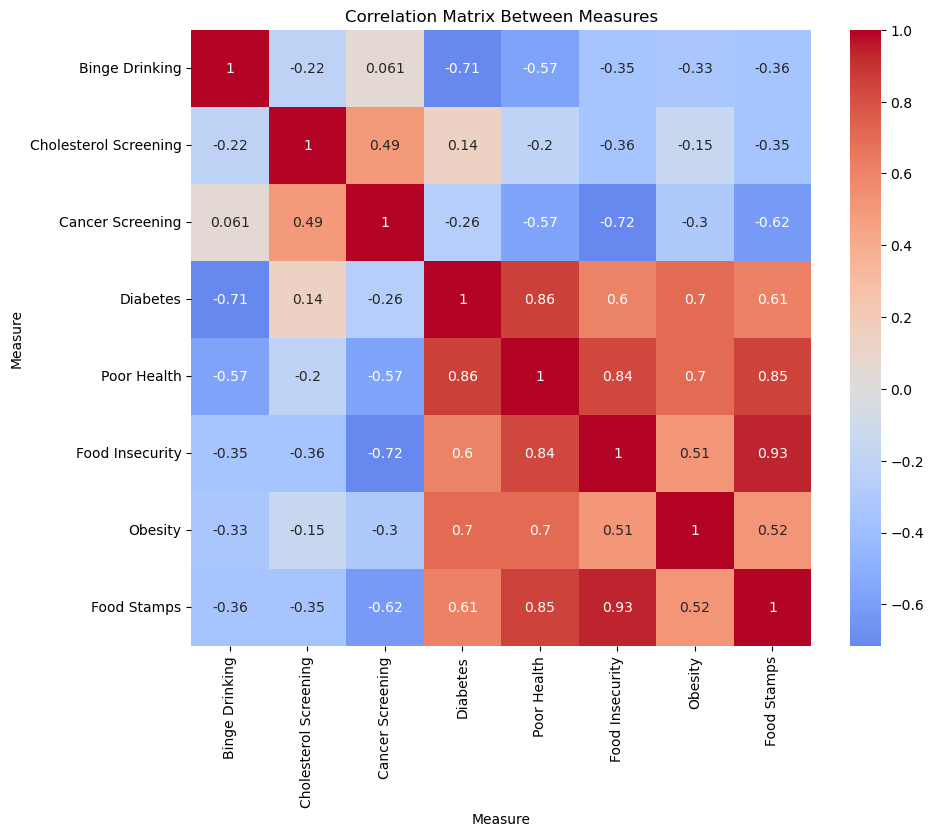

In [109]:
### visualize correlation with heatmap (matplotlib)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Between Measures")
plt.show()

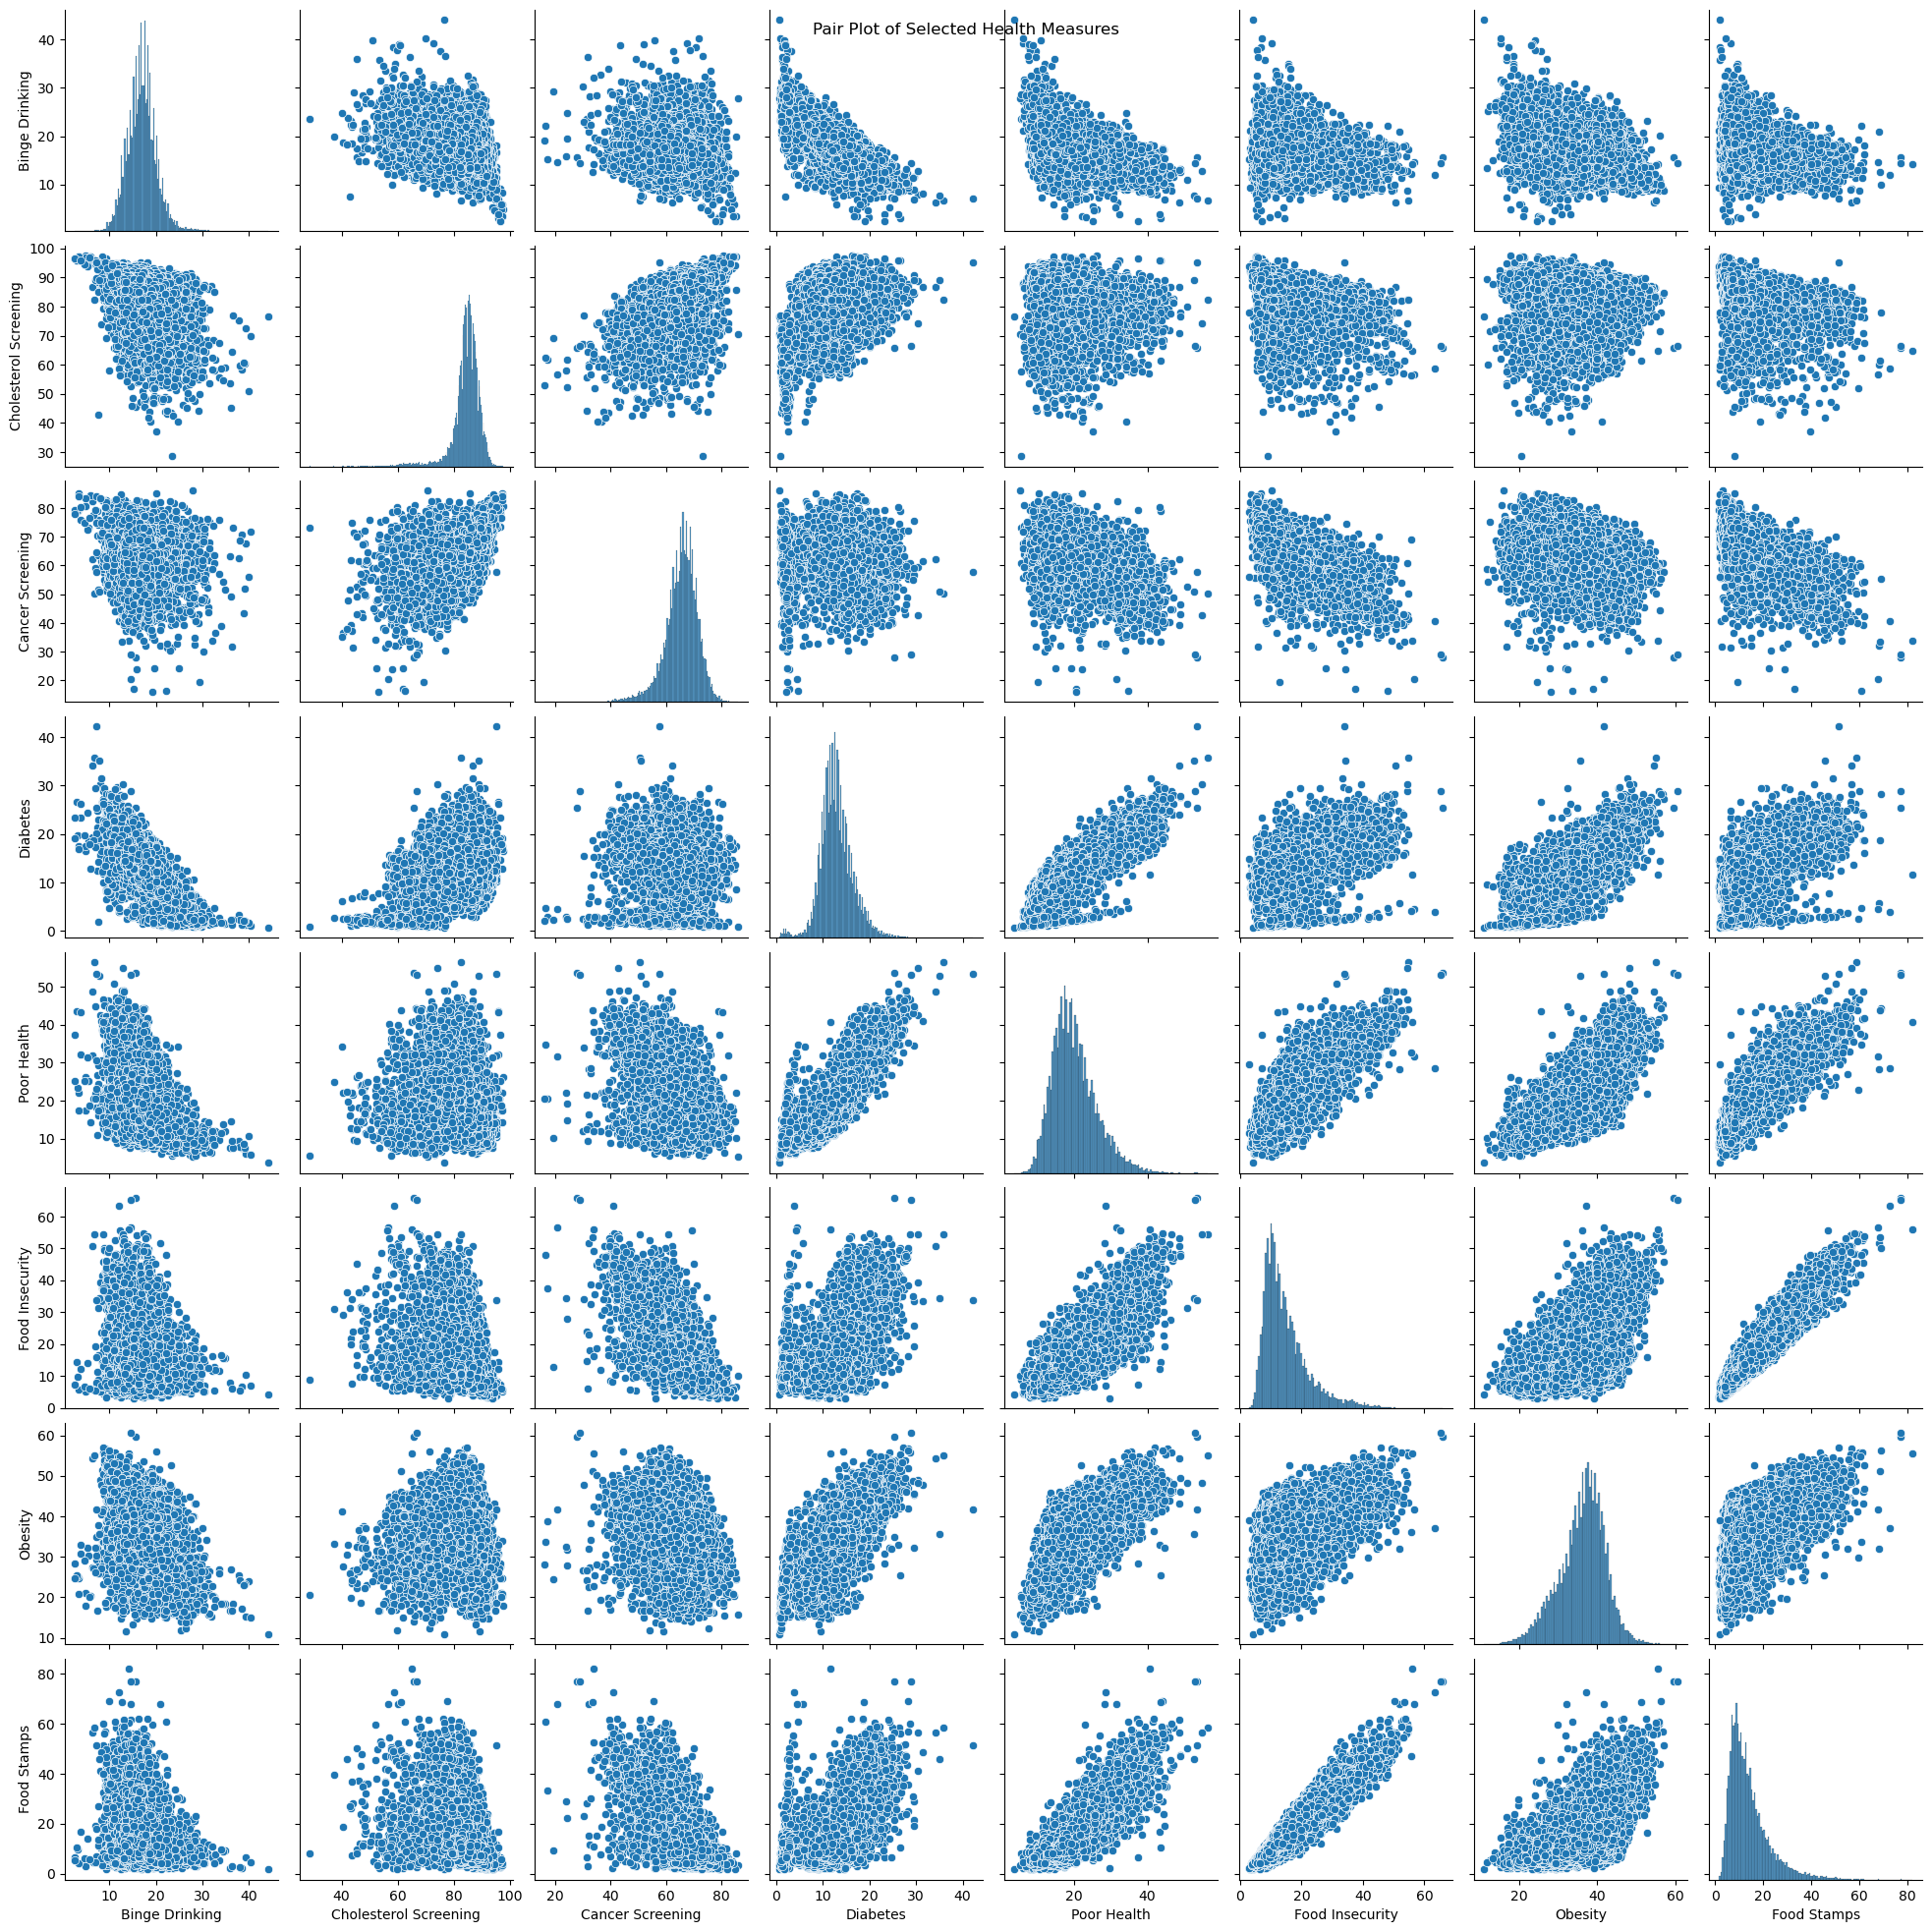

In [111]:
### pair plots

sns.pairplot(healthstatus_pivot_short)
plt.suptitle("Pair Plot of Selected Health Measures")
plt.show()

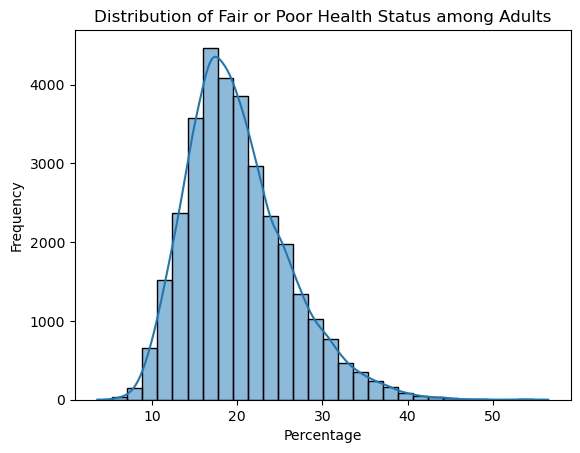

In [112]:
### distribution plot across zip codes
sns.histplot(data=healthstatus[healthstatus["Measure"] == "Fair or poor self-rated health status among adults"], x="Data_Value", kde=True, bins=30)
plt.title("Distribution of Fair or Poor Health Status among Adults")
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.show()

### Modeling: Linear Regression

In [114]:
### linear regression
variables = [
    "Food insecurity in the past 12 months among adults", 
    "Received food stamps in the past 12 months among adults", 
    "Diagnosed diabetes among adults", 
    "Obesity among adults",
    "Binge drinking among adults",
    "Cholesterol screening among adults",
    "Colorectal cancer screening among adults aged 45–75 years"
]

X = healthstatus_pivot[variables]
Y = healthstatus_pivot["Fair or poor self-rated health status among adults"]

### drop na values
X = X.dropna()
Y = Y[X.index]

### run model
X = sm.add_constant(X)
model = sm.OLS(Y, X).fit()
print(model.summary())

                                            OLS Regression Results                                            
Dep. Variable:     Fair or poor self-rated health status among adults   R-squared:                       0.937
Model:                                                            OLS   Adj. R-squared:                  0.937
Method:                                                 Least Squares   F-statistic:                 4.888e+04
Date:                                                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                                                        16:38:18   Log-Likelihood:                -42687.
No. Observations:                                               22898   AIC:                         8.539e+04
Df Residuals:                                                   22890   BIC:                         8.546e+04
Df Model:                                                           7                                         
C

#### Linear Regression
- r^2 = 0.937. 93.7 of the variation in Fair/Poor Self-Report Health Status is explained by variables in the model (model fits data well)
- F-statistic = 48,880 & p-value < 0.0001. Indicates model is statistically significant (independent variables significantly predict dependent variable)
- Coefficients of each independent variable
- - Food insecurity, food stamps, diabetes, and obesity had positive coefficients between 1.01 and 0.04 (increase in ind var = increase in dep var)
  - Binge drinking, cholesterol screening, and colorectal screening had negative coefficients between -0.07 and -0.16 (increase in ind var = decrease in dep var)
- Condition Number = 3260. May indicate multicollinearity between predictors. 

### Modeling: Logistic Regression

In [117]:
### logistic regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

### relevant measures
X = healthstatus_pivot_clean[["Food insecurity in the past 12 months among adults", 
    "Received food stamps in the past 12 months among adults", 
    "Diagnosed diabetes among adults", 
    "Obesity among adults",
    "Binge drinking among adults",
    "Cholesterol screening among adults",
    "Colorectal cancer screening among adults aged 45–75 years"
]]

### target variable (poor health is >= 20%)
threshold = 20
y = (healthstatus_pivot_clean["Fair or poor self-rated health status among adults"] >= threshold)

### preprocessing
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### split data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

### train model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

### predict with model
y_pred = log_reg.predict(X_test)

### evaluate model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.9301310043668122
Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.94      0.93      3663
        True       0.93      0.92      0.92      3207

    accuracy                           0.93      6870
   macro avg       0.93      0.93      0.93      6870
weighted avg       0.93      0.93      0.93      6870

Confusion Matrix:
 [[3451  212]
 [ 268 2939]]


### Logistic Regression
- Accuracy Score: 93% (model's predictions were correct on the test set)
- Classification Report
- - Precision: 93% successful prediction rate (how often did model predict True results)
  - Recall: 92% successful recall rate (how often did model recognize True results)
  - F1 Score: Harmonic mean of precision and recall (good balance between precision and recall)
  - Support: Number of examples in each class
- Confusion Matrix: Matrix for true negatives, true positives, false positives, and false negatives

Overall, this model shows that the relevant measures (food insecurity, diabetes, obesity) are strong predictors of whether a Zip Code has high vs low prevalence of poor self-rated health.  

In [118]:
### analyse coefficients to identify strongest predictors

feature_names = model.model.exog_names
coefficients = model.params

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

### sort for strongest predictors 
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=True)

print(coef_df_sorted[['Coefficient']])

                                                    Coefficient
Food insecurity in the past 12 months among adults     0.021764
Obesity among adults                                   0.047618
Binge drinking among adults                           -0.076271
Cholesterol screening among adults                    -0.096429
Colorectal cancer screening among adults aged 4...    -0.162718
Received food stamps in the past 12 months amon...     0.223367
Diagnosed diabetes among adults                        1.019555
const                                                 21.742550


#### Logistic Regression 
We can see that having diabetes has the largest coefficient, so it is has the strongest predictive influence on poor health status.

# Summary


#### Findings
Through this analysis, we have explored the relationship between various socio-economic and health-related factors and self-reported health status among adults. Key findings from the exploratory analysis revealed notable correlations between food insecurity, food stamp receipt, and health outcomes. Our statistical modeling identified several significant predictors, with diagnosed diabetes and food stamp receipt emerging as strong influencers of self-reported health status.

### Limitations
Despite the high model accuracy, it is important to consider the potential limitations, including missing data and the assumption of linear relationships between predictors and the target. Future work could explore additional predictors, refine the model by addressing multicollinearity, or apply more sophisticated techniques like decision trees or ensemble models for improved performance.

### Recommendations
Ultimately, the findings offer valuable insights into the factors that most significantly affect health outcomes which could inform public health strategies, policy development, and targeted interventions aimed at improving the well-being of at-risk populations.